In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("../datasets/Sunspots.csv")
df_raw = df.copy()
df["dummy"] = 1
df.shape, df.head()

((3265, 4),
    Unnamed: 0        Date  Monthly Mean Total Sunspot Number  dummy
 0           0  1749-01-31                               96.7      1
 1           1  1749-02-28                              104.3      1
 2           2  1749-03-31                              116.7      1
 3           3  1749-04-30                               92.8      1
 4           4  1749-05-31                              141.7      1)

In [ ]:
# df = df.head(35*12)
# df.shape

(420, 4)

In [18]:
288//12

24

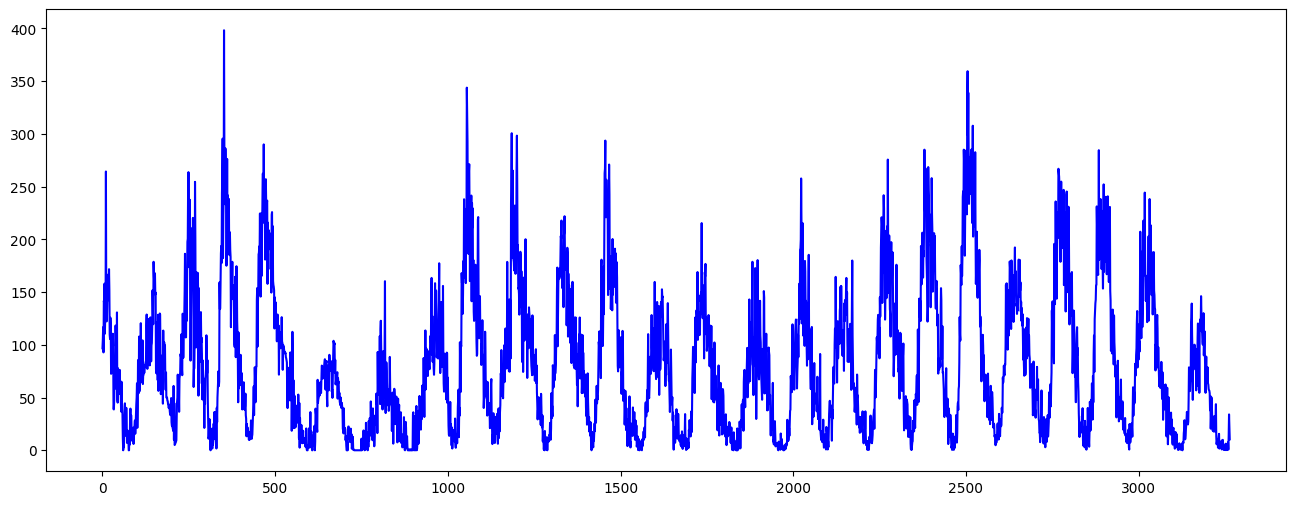

In [19]:
plt.figure(figsize=(16, 6))
plt.plot(df['Monthly Mean Total Sunspot Number'].values, c='b')

In [20]:
# make each numeric column smooth by rolling mean
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].rolling(window=20, min_periods=1).mean()
df.head(5)

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number,dummy
0,0.0,1749-01-31,96.700,1.0
1,0.5,1749-02-28,100.500,1.0
2,1.0,1749-03-31,105.900,1.0
3,1.5,1749-04-30,102.625,1.0
4,2.0,1749-05-31,110.440,1.0


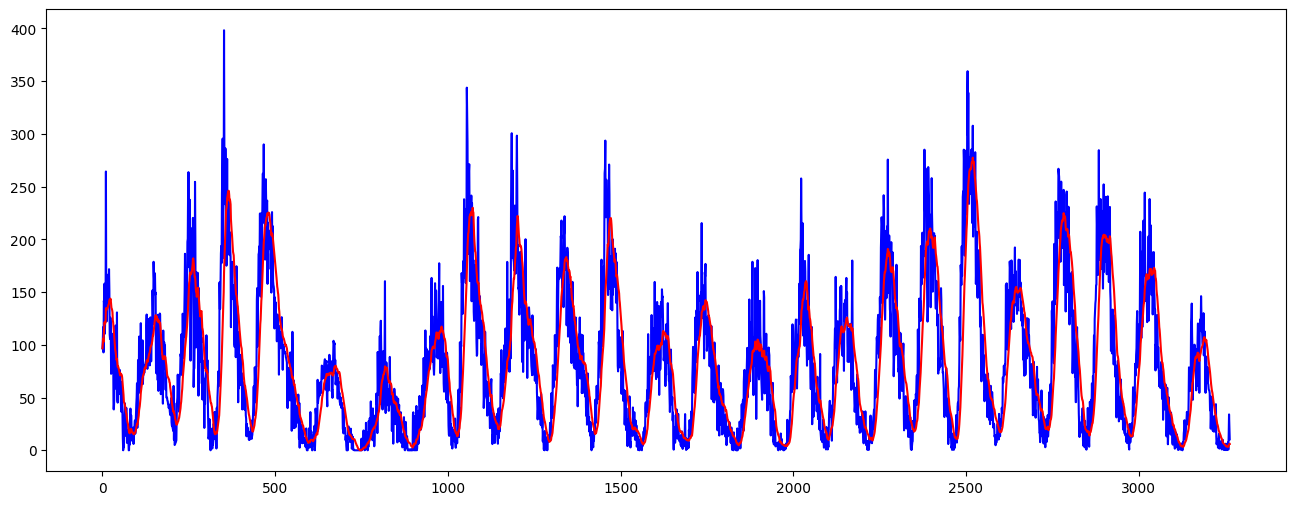

In [21]:
plt.figure(figsize=(16, 6))
plt.plot(df_raw["Monthly Mean Total Sunspot Number"], c='b')
plt.plot(df["Monthly Mean Total Sunspot Number"], c='r')


In [315]:
TOTAL_POINTS = len(df)
DAYS = 24
TRAIN_DAYS = 20
TEST_DAYS = 4
TIME = 12
FEATURES = 2
print(f"Tensor dimensions: {DAYS} x {TIME} x {FEATURES}")

Tensor dimensions: 24 x 12 x 2


In [317]:
data = df[['Monthly Mean Total Sunspot Number', 'dummy']][:DAYS*TIME].values

tensor = data.reshape(DAYS, TIME, FEATURES)
tensor.shape

(24, 12, 2)

In [318]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (20, 12, 2)
Test tensor shape: (4, 12, 2)


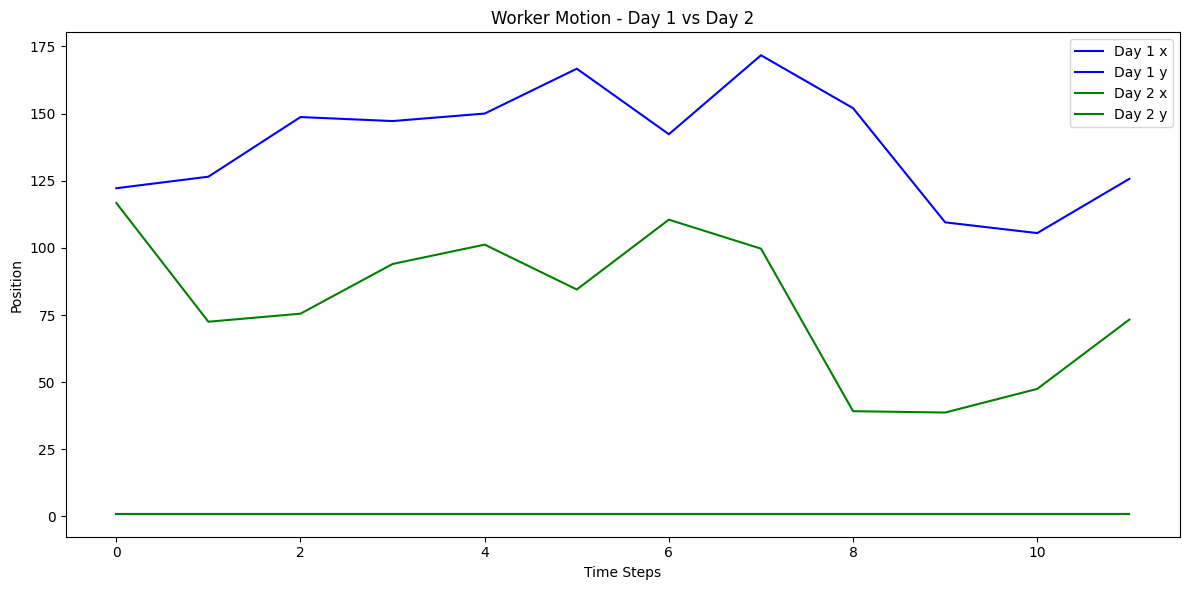

In [319]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [320]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (20, 2)
Time factors shape: (12, 2)
Feature factors shape: (2, 2)


In [322]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (20, 12, 2)
Reconstructed tensor shape: (20, 12, 2)


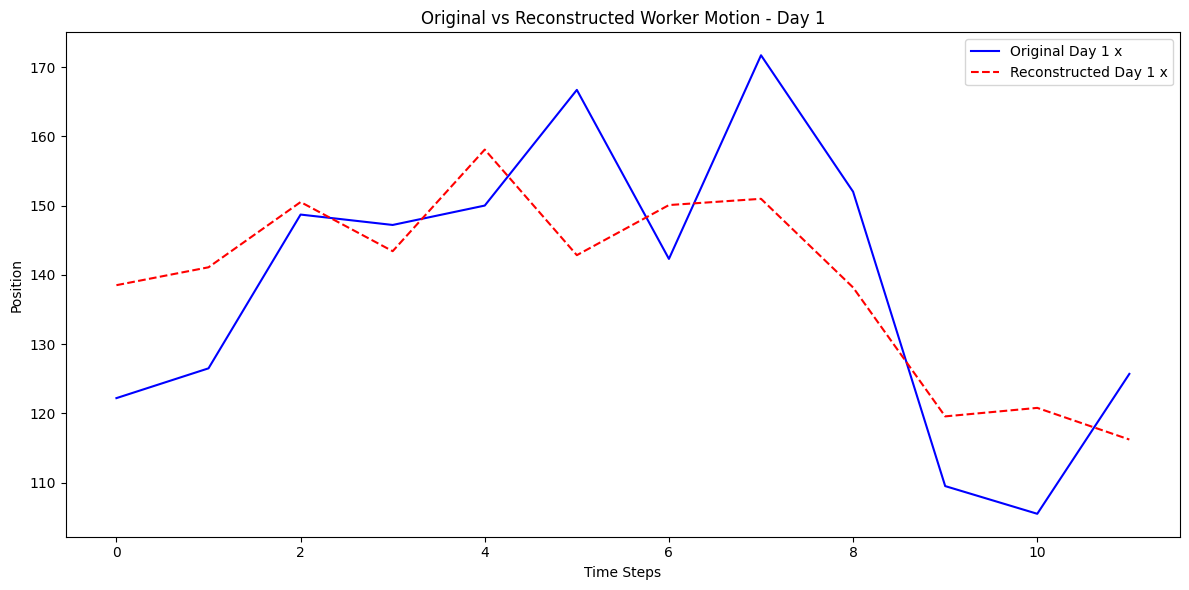

In [323]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [324]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

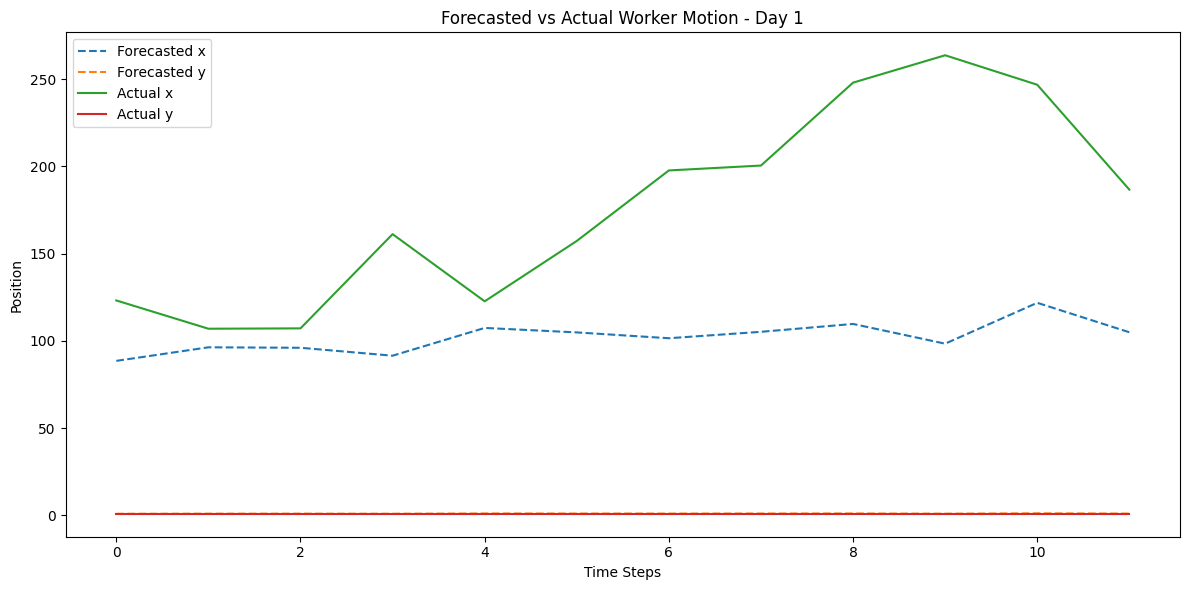

In [325]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

(288, 2) (288,)


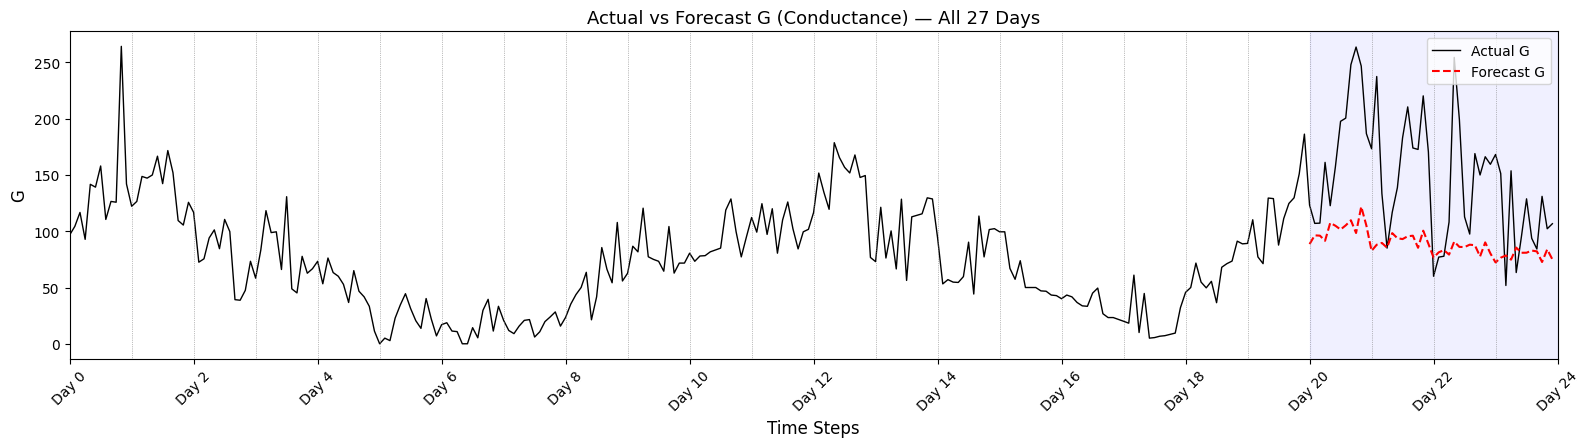

In [326]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)  # (648, 4) actual for all 27 days
print(full_series.shape, full_series[:,0].shape)
forecast_series = forecast_tensor.reshape(-1, FEATURES)  # (144, 4) forecast for days 22-27

T = DAYS * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 1)
# plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(x_forecast, forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, DAYS + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('G', fontsize=12)
plt.title('Actual vs Forecast G (Conductance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

# plt.subplot(2, 1, 2)
# plt.plot(x, full_series[:, 1], 'k-', lw=1, label='Actual B')
# plt.plot(x_forecast, forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
# for d in range(1, DAYS + 1):
#     plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
# plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
# plt.xticks(np.arange(0, T + 1, 2 * TIME),
#            [f'Day {d}' for d in range(0, DAYS + 1, 2)], rotation=45)
# plt.xlim(0, T)
# plt.ylabel('B', fontsize=12)
# plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
# plt.legend(loc='upper right')

plt.xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()

Test series shape: (48, 2)
Forecast series shape: (48, 2)
x shape: (48,)


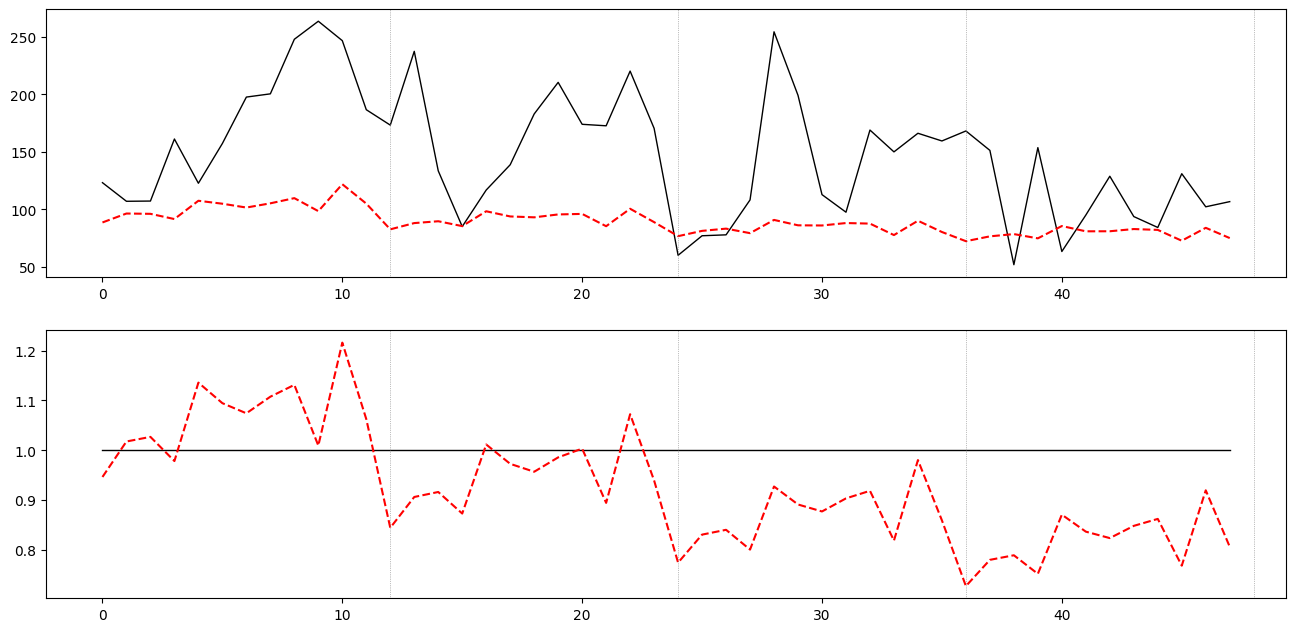

In [327]:
# Flatten full tensor and forecast tensor into time series
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)
plt.figure(figsize=(16, 16))

print(f"Test series shape: {test_series.shape}")
print(f"Forecast series shape: {forecast_series.shape}")
print(f"x shape: {x.shape}")

plt.subplot(4, 1, 1)
plt.plot(test_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 2)
plt.plot(test_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
# plt.subplot(4, 1, 3)
# plt.plot(test_series[:, 2], 'k-', lw=1, label='Actual C')
# plt.plot(forecast_series[:, 2], 'r--', lw=1.5, label='Forecast C')
# for d in range(1, TEST_DAYS + 1):
#     plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
# plt.subplot(4, 1, 4)
# plt.plot(test_series[:, 3], 'k-', lw=1, label='Actual D')
# plt.plot(forecast_series[:, 3], 'r--', lw=1.5, label='Forecast D')
# for d in range(1, TEST_DAYS + 1):
#     plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)


In [298]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((2200, 2), (200, 2))

In [299]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score

r2_a = r2_score(test_series[:, 0], forecast_series[:, 0])
r2_b = r2_score(test_series[:, 1], forecast_series[:, 1])

r2_scores = {
    'Col 1': r2_a,
    'Col 2': r2_b,
}

r2_scores_df = pd.DataFrame(list(r2_scores.items()), columns=['Column', 'R² Score'])
print(r2_scores_df)

  Column  R² Score
0  Col 1   0.51581
1  Col 2   0.00000


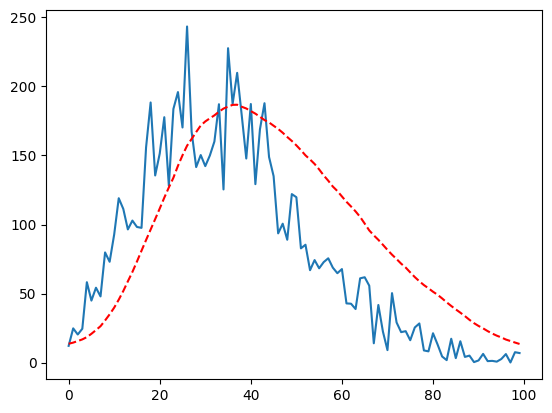

In [303]:
# Build a raw tensor the same way as 'tensor' but from raw data
raw_signal = df_raw["Monthly Mean Total Sunspot Number"].values
raw_cycles = []
for i in range(len(mins) - 1):
    cycle = raw_signal[mins[i]:mins[i+1]+1]
    x_old = np.linspace(0, 1, len(cycle))
    x_new = np.linspace(0, 1, TARGET_LENGTH)
    raw_cycles.append(PchipInterpolator(x_old, cycle)(x_new))
raw_tensor = np.stack((np.array(raw_cycles), np.ones_like(raw_cycles)), axis=-1)

# Now plot raw vs forecast for a specific day
plt.plot(raw_tensor[22, :, 0], label='Raw (resampled)')
plt.plot(forecast_tensor[0, :, 0], 'r--', label='Predicted')